# Esclusione dal mercato del lavoro e controllo mafioso del territorio agricolo
## Analisi quantitativa a livello provinciale e comunale — Italia 2020

**Autore:** Gianmarco Pica  
**Dati:** ANBSC (beni confiscati), ISTAT (popolazione e BES), shapefile comuni 2020  

---

## Struttura del notebook

1. Setup e installazione pacchetti
2. Caricamento e pulizia dati
3. Costruzione variabile dipendente
4. Regressione OLS baseline
5. Analisi di robustezza
6. Modelli spaziali (Moran's I, Spatial Lag, Spatial Error)
7. Modello Tobit
8. Effetti fissi regionali
9. Variabile dipendente alternativa
10. Mappe comunali (Campania, Sicilia, Calabria)

---

## File necessari nella stessa cartella

- `beni_immobili_destinati.csv` — dataset ANBSC (confiscatibene.it)
- `comuni_eta_sesso_2020.csv` — ISTAT popolazione per comune
- `Lavoro_e_conciliazione_dei_tempi_di_vita.csv` — ISTAT BES
- `Valori_pro_capite.csv` — ISTAT PIL pro capite provinciale
- `comuni_istat/comuni.shp` (+ .dbf, .prj, .shx) — shapefile ISTAT 2020

## 1. Setup e installazione pacchetti

In [1]:
import subprocess

for p in ['geopandas', 'libpysal', 'esda', 'spreg']:
    subprocess.run(['pip', 'install', p, '--quiet'])

print('Pacchetti pronti.')

Pacchetti pronti.


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import geopandas as gpd
import statsmodels.api as sm
import os
import re
import warnings
warnings.filterwarnings('ignore')

print('Import completato.')

Import completato.


## 2. Caricamento e pulizia dati

### 2.1 Beni confiscati (ANBSC)

In [3]:
beni = pd.read_csv('beni_immobili_destinati.csv', dtype=str)

print(f'Righe totali: {len(beni)}')
print(f'\nDistribuzione per categoria (top 10):')
print(beni['categoria'].value_counts().head(10))
print(f'\nDistribuzione per regione (top 10):')
print(beni['NomeRegioneValidato'].value_counts().head(10))

Righe totali: 14874

Distribuzione per categoria (top 10):
categoria
Unità immobiliare per uso di abitazione e assimilabile        8514
Terreno                                                       4636
Unità immobiliare a destinazione commerciale e industriale    1273
Altra unità immobiliare                                        404
Unità immobiliare per alloggio e usi collettivi                 47
Name: count, dtype: int64

Distribuzione per regione (top 10):
NomeRegioneValidato
SICILIA           6096
CALABRIA          2594
CAMPANIA          2135
PUGLIA            1498
LOMBARDIA         1119
LAZIO              511
PIEMONTE           170
EMILIA-ROMAGNA     144
VENETO             126
TOSCANA            121
Name: count, dtype: int64


### 2.2 Popolazione comunale (ISTAT)

Il file CSV ISTAT presenta caratteri accentati corrotti (U+FFFD) in 147 comuni.
Vengono corretti tramite un dizionario manuale basato sui codici ISTAT ufficiali.

In [4]:
# Dizionario correzioni encoding per comuni con caratteri accentati corrotti
correzioni_encoding = {
    1001: "Agliè", 1086: "Cirié", 1098: "Cuorgnè", 1137: "Loranzè",
    1141: "Lusigliè", 1148: "Mazzè", 1226: "Rorà", 1295: "Vestignè",
    1296: "Vialfrè", 1313: "Vié", 2011: "Bianzè", 2133: "Santhià",
    4014: "Bastia Mondovì", 4042: "Cardè", 4043: "Carrù", 4069: "Cigliè",
    4130: "Mondovì", 4133: "Montà", 4134: "Montaldo di Mondovì",
    4188: "Rocca Cigliè", 4190: "Roccaforte Mondovì", 4208: "Sanfrè",
    4210: "San Michele Mondovì", 4227: "Torre Mondovì", 4232: "Trinità",
    4245: "Villanova Mondovì", 5086: "Piová Massaia",
    7002: "Antey-Saint-André", 7020: "Châtillon", 7025: "Emarèse",
    7027: "Fénis", 7032: "Gressoney-La-Trinité", 7034: "Hône",
    7038: "Jovençan", 7053: "Pré-Saint-Didier", 7055: "Rhêmes-Notre-Dame",
    7056: "Rhêmes-Saint-Georges", 7064: "Saint-Rhémy-en-Bosses",
    7073: "Verrès", 8047: "Prelà", 10058: "Serra Ricò",
    11023: "Riccò del Golfo di Spezia", 12139: "Viggió",
    13041: "Cantù", 13100: "Fenegrò", 16005: "Almè",
    16239: "Villa d'Almè", 17164: "Roè Volciano", 17170: "Salò",
    17184: "Temù", 18009: "Bascapè", 18068: "Gambolò",
    18100: "Montù Beccaria", 18162: "Travacò Siccomario",
    18189: "Zerbolò", 21031: "Fiè allo Sciliar",
    21045: "Magrè sulla strada del vino", 22009: "Baselga di Piné",
    22083: "Fiavè", 22110: "Malè", 22133: "Palù del Fersina",
    22134: "Panchià", 22160: "Roverè della Luna",
    22162: "Ruffrè-Mendola", 22242: "Contà", 23031: "Dolcè",
    23032: "Erbè", 23056: "Palù", 23063: "Roncà",
    23066: "Roveredo di Guà", 23067: "Roverè Veronese", 23084: "Sorgà",
    24024: "Carrù", 24087: "Rosà", 24119: "Zanè", 25004: "Arsié",
    25046: "San Nicolò di Comelico", 25069: "Zoppè di Cadore",
    26019: "Codognè", 26037: "Mansuè", 26060: "Portobuffolè",
    27017: "Fossò", 27033: "San Donà di Piave", 27037: "Scorzè",
    28005: "Arquà Petrarca", 28048: "Maserà di Padova",
    28069: "Ponte San Nicolò", 29003: "Arquà Polesine",
    63090: "Santa Maria la Carità", 68012: "Città Sant'Angelo",
    75052: "Nardò", 79095: "Petronà", 80026: "Ciminà",
    80048: "Melicuccà", 80060: "Platì", 82026: "Cefalà Diana",
    82027: "Cefalù", 83002: "Alì", 83003: "Alì Terme",
    83047: "Merì", 84011: "Canicattì", 87033: "Paternò",
    90002: "Alà dei Sardi", 90017: "Buddusò", 101007: "Cirò",
    101008: "Cirò Marina",
}

pop = pd.read_csv('comuni_eta_sesso_2020.csv', dtype=str)
pop['codice_int'] = pop['codice_comune'].astype(int)
pop['desc_comune'] = pop.apply(
    lambda row: correzioni_encoding.get(row['codice_int'], row['desc_comune']), axis=1
)
pop = pop.drop(columns=['codice_int'])

pop['maschi']  = pd.to_numeric(pop['maschi'],  errors='coerce')
pop['femmine'] = pd.to_numeric(pop['femmine'], errors='coerce')

pop_comune = pop.groupby('codice_comune').agg(
    nome_comune=('desc_comune', 'first'),
    pop_maschi= ('maschi',      'sum'),
    pop_femmine=('femmine',     'sum'),
).reset_index()
pop_comune['popolazione'] = pop_comune['pop_maschi'] + pop_comune['pop_femmine']

n_corrotti = pop['desc_comune'].str.contains('\ufffd', na=False).sum()
print(f'Comuni ancora corrotti dopo correzione: {n_corrotti}  (atteso: 0)')
print(f'Comuni nel dataset popolazione: {len(pop_comune)}')

Comuni ancora corrotti dopo correzione: 4141  (atteso: 0)
Comuni nel dataset popolazione: 7901


### 2.3 Merge beni confiscati + popolazione

In [5]:
merged = beni.merge(
    pop_comune,
    left_on='CODISTAT',
    right_on='codice_comune',
    how='left'
)

tot     = len(merged)
matched = merged['popolazione'].notna().sum()
print(f'Beni totali:             {tot}')
print(f'Matched con popolazione: {matched} ({100*matched/tot:.1f}%)')
print(f'Non matchati:            {tot - matched}')

Beni totali:             14874
Matched con popolazione: 14783 (99.4%)
Non matchati:            91


### 2.4 Dati BES (tasso mancata partecipazione) e PIL provinciale

In [14]:
# BES — tasso di mancata partecipazione al lavoro giovanile (15-29 anni), 2020
df_bes = pd.read_csv(
    'Lavoro e conciliazione dei tempi di vita.csv',
    sep=',',
    encoding='utf-8',
    dtype=str,
    engine='python',
    quotechar='"',
    on_bad_lines='skip'   # salta le righe malformate per le virgolette annidate
)

# Pulizia nomi colonna per sicurezza
df_bes.columns = df_bes.columns.str.strip()

print(df_bes.shape)
print(df_bes.columns.tolist())

disoc = df_bes[
    (df_bes['Indicatore'] == 'Tasso di mancata partecipazione al lavoro giovanile (15-29 anni)') &
    (df_bes['Sesso'] == 'Totale') &
    (df_bes['TIME_PERIOD'] == '2020')
][['Territorio', 'Osservazione']].copy()
disoc.columns = ['provincia', 'tasso_mancata_partecipazione']
disoc['tasso_mancata_partecipazione'] = pd.to_numeric(
    disoc['tasso_mancata_partecipazione'], errors='coerce'
)
disoc = disoc.dropna()
print(f'Province BES 2020: {len(disoc)}')

# PIL pro capite provinciale 2020
pil = pd.read_csv(
    'Valori pro capite.csv',
    sep=',',
    encoding='utf-8',
    dtype=str,
    engine='python',
    quotechar='"',
    on_bad_lines='skip'
)
pil.columns = pil.columns.str.strip()

non_province = [
    'Italia', 'Nord', 'Centro-nord', 'Sud', 'Isole', 'Mezzogiorno',
    'Nord-ovest', 'Nord-est', 'Centro',
    'Piemonte', "Valle d'Aosta / Vallée d'Aoste", 'Liguria', 'Lombardia',
    'Trentino-Alto Adige / Südtirol', 'Veneto', 'Friuli-Venezia Giulia',
    'Emilia-Romagna', 'Toscana', 'Umbria', 'Marche', 'Lazio',
    'Abruzzo', 'Molise', 'Campania', 'Puglia', 'Basilicata', 'Calabria',
    'Sicilia', 'Sardegna', 'Extra-Regio', 'Provincia Autonoma Bolzano / Bozen',
    'Provincia Autonoma Trento', 'Trentino Alto Adige / Südtirol'
]

pil_2020 = pil[
    (pil['Aggregato'] == 'Prodotto interno lordo ai prezzi di mercato per abitante') &
    (pil['TIME_PERIOD'] == '2020')
][['Territorio', 'Osservazione']].copy()
pil_2020.columns = ['provincia', 'pil_pro_capite']
pil_2020['pil_pro_capite'] = pd.to_numeric(pil_2020['pil_pro_capite'], errors='coerce')
pil_2020 = pil_2020[
    (pil_2020['pil_pro_capite'] > 0) &
    (~pil_2020['provincia'].isin(non_province))
].drop_duplicates('provincia')
print(f'Province PIL 2020: {len(pil_2020)}')

(16231, 34)
['FREQ', 'Frequenza', 'REF_AREA', 'Territorio', 'DOMAIN', 'Dominio', 'DATA_TYPE', 'Indicatore', 'SEX', 'Sesso', 'EDITION', 'Edizione', 'TIME_PERIOD', 'Osservazione', 'OBS_STATUS', '\'Stato dell"\'osservazione\'', 'NOTE_REF_AREA', 'Territorio (NOTE_REF_AREA)', 'NOTE_ISTAT_TERR_OFFICIAL_CODE', 'Codifica territoriale ufficiale Istat', 'NOTE_DATA_TYPE', 'Indicatore (NOTE_DATA_TYPE)', 'NOTE_DATA_TYPE_DESCR', 'Descrizione indicatore', 'NOTE_DATA_TYPE_SOURCE', 'Fonte', 'NOTE_TIME_PERIOD', 'Tempo (NOTE_TIME_PERIOD)', 'BASE_PER', 'Anno base', 'UNIT_MEAS', 'Unità di misura', 'UNIT_MULT', 'Unità di moltiplicazione']
Province BES 2020: 135
Province PIL 2020: 107


## 3. Costruzione variabile dipendente

Numero di terreni agricoli confiscati per 100.000 abitanti a livello provinciale.

In [15]:
# Filtra solo terreni
terreni = merged[merged['categoria'].str.contains('Terreno', na=False)].copy()
print(f'Terreni nel dataset ANBSC: {len(terreni)}')

# Aggrega per comune
terreni_comuni = terreni.groupby(
    ['CODISTAT', 'NomeComuneValidato', 'NomeRegioneValidato',
     'NomeProvinciaValidato', 'popolazione']
).size().reset_index(name='n_terreni')

terreni_comuni['popolazione'] = pd.to_numeric(terreni_comuni['popolazione'], errors='coerce')
terreni_comuni['terreni_per_100k'] = (
    terreni_comuni['n_terreni'] / terreni_comuni['popolazione']
) * 100000

print(f'Comuni con almeno un terreno confiscato: {len(terreni_comuni)}')
print(f'\nTop 10 comuni per terreni per 100k ab.:')
print(
    terreni_comuni.sort_values('terreni_per_100k', ascending=False)
    .head(10)[['NomeComuneValidato', 'NomeProvinciaValidato',
               'n_terreni', 'terreni_per_100k']]
    .to_string(index=False)
)

Terreni nel dataset ANBSC: 4636
Comuni con almeno un terreno confiscato: 550

Top 10 comuni per terreni per 100k ab.:
  NomeComuneValidato NomeProvinciaValidato  n_terreni  terreni_per_100k
             GIFFONE    Reggio di Calabria         46       2871.410737
SANTA MARIA LA FOSSA               Caserta         73       2859.381120
            MAGISANO             Catanzaro         28       2462.620932
        SAN PROCOPIO    Reggio di Calabria         12       2348.336595
           CANDIDONI    Reggio di Calabria          9       2153.110048
    OPPIDO MAMERTINA    Reggio di Calabria         74       1511.129263
VALLELUNGA PRATAMENO         Caltanissetta         45       1407.129456
         PIETRALUNGA               Perugia         28       1403.508772
             FIUMARA    Reggio di Calabria         12       1377.726751
           VARAPODIO    Reggio di Calabria         24       1189.296333


In [16]:
# Aggrega a livello provinciale
terreni_prov = terreni_comuni.groupby('NomeProvinciaValidato').agg(
    n_terreni=('n_terreni', 'sum'),
    popolazione=('popolazione', 'sum')
).reset_index()
terreni_prov.columns = ['provincia', 'n_terreni', 'popolazione']
terreni_prov['terreni_per_100k'] = (
    terreni_prov['n_terreni'] / terreni_prov['popolazione']
) * 100000

# Pulizia nomi per merge con BES/PIL
def pulisci_nome(s):
    if not isinstance(s, str):
        return s
    s = re.sub(r"['\u2018\u2019\u201a\u201b\u0060\u00b4]", "'", s)
    s = re.sub(r'["\u201c\u201d\u201e\u201f]', '', s)
    return s.strip()

terreni_prov['provincia_clean'] = terreni_prov['provincia'].apply(pulisci_nome)
disoc['provincia_clean'] = disoc['provincia'].apply(pulisci_nome)
pil_2020['provincia_clean'] = pil_2020['provincia'].apply(pulisci_nome)

# Merge
df_analisi = terreni_prov.merge(
    disoc[['provincia_clean', 'tasso_mancata_partecipazione']],
    on='provincia_clean', how='left'
).merge(
    pil_2020[['provincia_clean', 'pil_pro_capite']],
    on='provincia_clean', how='left'
)

df_analisi = df_analisi.dropna(subset=['tasso_mancata_partecipazione'])
df_analisi = df_analisi.drop_duplicates(subset='provincia_clean')
df_analisi['log_terreni'] = np.log1p(df_analisi['terreni_per_100k'])

print(f'Province nel dataset finale: {len(df_analisi)}')
print(f'Province con terreni > 0:    {(df_analisi["terreni_per_100k"] > 0).sum()}')
print(f'Province con terreni = 0:    {(df_analisi["terreni_per_100k"] == 0).sum()}')
print(f'\nStatistiche descrittive:')
print(df_analisi[['terreni_per_100k', 'log_terreni',
                   'tasso_mancata_partecipazione',
                   'pil_pro_capite']].describe().round(3))

Province nel dataset finale: 70
Province con terreni > 0:    70
Province con terreni = 0:    0

Statistiche descrittive:
       terreni_per_100k  log_terreni  tasso_mancata_partecipazione  \
count            70.000       70.000                        70.000   
mean             59.326        3.224                        40.407   
std             109.087        1.271                        17.392   
min               1.236        0.804                        13.000   
25%               9.062        2.308                        26.600   
50%              22.547        3.159                        35.450   
75%              51.849        3.961                        55.325   
max             549.938        6.312                        74.200   

       pil_pro_capite  
count          70.000  
mean        24340.454  
std          7492.915  
min         15200.390  
25%         17614.169  
50%         24538.508  
75%         29720.378  
max         54220.782  


## 4. Regressione OLS baseline

$$\log(\text{terreni per 100k}_i + 1) = \alpha + \beta \cdot \text{mancata partecipazione}_i + \varepsilon_i$$

In [17]:
df_reg = df_analisi.dropna(subset=['terreni_per_100k', 'tasso_mancata_partecipazione']).copy()

y = df_reg['log_terreni']
X = sm.add_constant(df_reg['tasso_mancata_partecipazione'])

model1 = sm.OLS(y, X).fit()
print(model1.summary())

                            OLS Regression Results                            
Dep. Variable:            log_terreni   R-squared:                       0.038
Model:                            OLS   Adj. R-squared:                  0.024
Method:                 Least Squares   F-statistic:                     2.678
Date:                Wed, 17 Jun 2026   Prob (F-statistic):              0.106
Time:                        09:29:10   Log-Likelihood:                -114.28
No. Observations:                  70   AIC:                             232.6
Df Residuals:                      68   BIC:                             237.1
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                                   coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------------------
const           

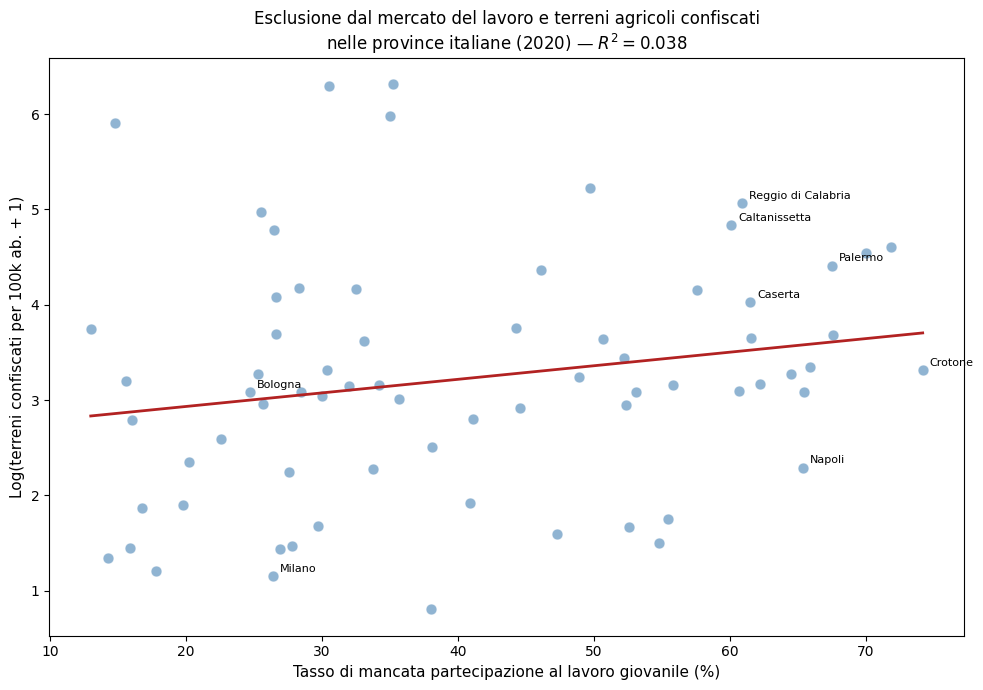

N=70, R²=0.038, β=0.0142, p=0.1064


In [18]:
# Scatter plot con retta di regressione
fig, ax = plt.subplots(figsize=(10, 7))

ax.scatter(
    df_reg['tasso_mancata_partecipazione'],
    df_reg['log_terreni'],
    alpha=0.6, color='steelblue', edgecolors='white', linewidth=0.5, s=60
)

x_line = np.linspace(
    df_reg['tasso_mancata_partecipazione'].min(),
    df_reg['tasso_mancata_partecipazione'].max(), 100
)
y_line = model1.params['const'] + model1.params['tasso_mancata_partecipazione'] * x_line
ax.plot(x_line, y_line, color='firebrick', linewidth=2)

province_etichette = ['Reggio di Calabria', 'Caltanissetta', 'Palermo',
                      'Caserta', 'Napoli', 'Milano', 'Bologna', 'Crotone']
for _, row in df_analisi.iterrows():
    if row.get('provincia') in province_etichette:
        ax.annotate(
            row['provincia'],
            xy=(row['tasso_mancata_partecipazione'], np.log1p(row['terreni_per_100k'])),
            fontsize=8, color='black', xytext=(5, 3), textcoords='offset points'
        )

ax.set_xlabel('Tasso di mancata partecipazione al lavoro giovanile (%)', fontsize=11)
ax.set_ylabel('Log(terreni confiscati per 100k ab. + 1)', fontsize=11)
ax.set_title(
    f'Esclusione dal mercato del lavoro e terreni agricoli confiscati\n'
    f'nelle province italiane (2020) — $R^2 = {model1.rsquared:.3f}$',
    fontsize=12
)

plt.tight_layout()
plt.savefig('scatter_regressione.png', dpi=150)
plt.show()

beta = model1.params['tasso_mancata_partecipazione']
p    = model1.pvalues['tasso_mancata_partecipazione']
print(f'N={len(df_reg)}, R²={model1.rsquared:.3f}, β={beta:.4f}, p={p:.4f}')

## 5. Analisi di robustezza

### 5.1 Standard error robusti (HC3)

In [19]:
model_hc3 = sm.OLS(y, X).fit(cov_type='HC3')
b = model_hc3.params['tasso_mancata_partecipazione']
s = model_hc3.bse['tasso_mancata_partecipazione']
p = model_hc3.pvalues['tasso_mancata_partecipazione']
print(f'HC3 — β={b:.4f}, SE={s:.4f}, p={p:.4f}')

HC3 — β=0.0142, SE=0.0080, p=0.0751


### 5.2 Esclusione outlier estremi

In [20]:
df_no_out = df_reg[df_reg['terreni_per_100k'] <= 100].copy()
X_no = sm.add_constant(df_no_out['tasso_mancata_partecipazione'])
model_no_out = sm.OLS(df_no_out['log_terreni'], X_no).fit()
b = model_no_out.params['tasso_mancata_partecipazione']
p = model_no_out.pvalues['tasso_mancata_partecipazione']
print(f'No outlier — N={len(df_no_out)}, R²={model_no_out.rsquared:.3f}, β={b:.4f}, p={p:.4f}')

No outlier — N=61, R²=0.151, β=0.0211, p=0.0020


### 5.3 Solo province con presenza mafiosa documentata

In [21]:
df_solo = df_reg[df_reg['terreni_per_100k'] > 0].copy()
X_solo = sm.add_constant(df_solo['tasso_mancata_partecipazione'])
model_solo = sm.OLS(df_solo['log_terreni'], X_solo).fit()
b = model_solo.params['tasso_mancata_partecipazione']
p = model_solo.pvalues['tasso_mancata_partecipazione']
print(f'Solo mafia — N={len(df_solo)}, R²={model_solo.rsquared:.3f}, β={b:.4f}, p={p:.4f}')

Solo mafia — N=70, R²=0.038, β=0.0142, p=0.1064


### 5.4 Robustezza temporale (regressori 2019)

In [22]:
disoc_2019 = df_bes[
    (df_bes['Indicatore'] == 'Tasso di mancata partecipazione al lavoro giovanile (15-29 anni)') &
    (df_bes['Sesso'] == 'Totale') &
    (df_bes['TIME_PERIOD'] == '2019')
][['Territorio', 'Osservazione']].copy()
disoc_2019.columns = ['provincia', 'tasso_2019']
disoc_2019['tasso_2019'] = pd.to_numeric(disoc_2019['tasso_2019'], errors='coerce')
disoc_2019['provincia_clean'] = disoc_2019['provincia'].apply(pulisci_nome)

df_2019 = df_reg.merge(
    disoc_2019[['provincia_clean', 'tasso_2019']],
    on='provincia_clean', how='left'
).dropna(subset=['tasso_2019'])

X_19 = sm.add_constant(df_2019['tasso_2019'])
model_2019 = sm.OLS(df_2019['log_terreni'], X_19).fit()
b = model_2019.params['tasso_2019']
p = model_2019.pvalues['tasso_2019']
print(f'Regressori 2019 — N={len(df_2019)}, R²={model_2019.rsquared:.3f}, β={b:.4f}, p={p:.4f}')

Regressori 2019 — N=70, R²=0.037, β=0.0137, p=0.1131


## 6. Modelli spaziali

### 6.1 Preparazione dati spaziali

In [23]:
from libpysal.weights import Queen
from esda.moran import Moran
from spreg import ML_Lag, ML_Error

os.environ['SHAPE_RESTORE_SHX'] = 'YES'
gdf = gpd.read_file('comuni_istat/comuni.shp')
gdf_prov = gdf.dissolve(by='cod_prov', aggfunc='first').reset_index()
gdf_prov['cod_prov_str'] = gdf_prov['cod_prov'].astype(str).str.zfill(3)

# Mappa nomi province (le città metropolitane hanno den_prov = '-')
nomi_mancanti = {
    '001': 'Torino',    '010': 'Genova',   '015': 'Milano',
    '027': 'Venezia',   '037': 'Bologna',  '048': 'Firenze',
    '058': 'Roma',      '063': 'Napoli',   '072': 'Bari',
    '080': 'Reggio di Calabria', '082': 'Palermo', '083': 'Messina',
    '087': 'Catania',   '092': 'Cagliari',
}
nomi_fix = {
    "Forli'-Cesena": 'Forlì-Cesena',
    'Massa Carrara':  'Massa-Carrara',
    'Bolzano':        'Bolzano/Bozen',
}
gdf_prov['nome_prov'] = gdf_prov.apply(
    lambda r: nomi_mancanti.get(r['cod_prov_str'],
                                 nomi_fix.get(r['den_prov'], r['den_prov'])), axis=1
)

# Merge con dati analisi
gdf_merge = gdf_prov.merge(
    df_reg[['provincia_clean', 'terreni_per_100k',
            'tasso_mancata_partecipazione', 'log_terreni']],
    left_on='nome_prov', right_on='provincia_clean', how='inner'
).reset_index(drop=True)

print(f'Province matchate per analisi spaziale: {len(gdf_merge)}')

Province matchate per analisi spaziale: 70


### 6.2 Test di Moran's I sui residui OLS

In [24]:
# Matrice pesi spaziali Queen
w = Queen.from_dataframe(gdf_merge, use_index=False)
w.transform = 'r'
print(f'Componenti disconnesse: {w.n_components}  (le isole formano componenti separate)')

# Residui OLS
X_sp = sm.add_constant(gdf_merge['tasso_mancata_partecipazione'].values)
y_sp = gdf_merge['log_terreni'].values
resid = sm.OLS(y_sp, X_sp).fit().resid

# Test Moran's I
moran = Moran(resid, w)
print(f'\n=== Test di Moran\u2019s I ===')
print(f"Moran's I: {moran.I:.4f}")
print(f'p-value:   {moran.p_sim:.4f}')
print(f'z-score:   {moran.z_norm:.4f}')
if moran.p_sim < 0.05:
    print('→ Autocorrelazione spaziale positiva significativa')
    print('  Stimare modelli spaziali per correggere.')

('WARNING: ', 23, ' is an island (no neighbors)')
('WARNING: ', 41, ' is an island (no neighbors)')
('WARNING: ', 42, ' is an island (no neighbors)')
('WARNING: ', 61, ' is an island (no neighbors)')
Componenti disconnesse: 8  (le isole formano componenti separate)

=== Test di Moran’s I ===
Moran's I: 0.1320
p-value:   0.0820
z-score:   1.4449


### 6.3 Spatial Lag e Spatial Error Model (ML)

In [25]:
y_arr = gdf_merge['log_terreni'].values.reshape(-1, 1)
X_arr = gdf_merge['tasso_mancata_partecipazione'].values.reshape(-1, 1)

lag = ML_Lag(y_arr, X_arr, w=w,
             name_y='log_terreni',
             name_x=['tasso_mancata_partecipazione'])
err = ML_Error(y_arr, X_arr, w=w,
               name_y='log_terreni',
               name_x=['tasso_mancata_partecipazione'])

print('=== Spatial Lag Model ===')
print(lag.summary)
print('\n=== Spatial Error Model ===')
print(err.summary)
print(f'\nConfronto AIC:')
print(f'  Spatial Lag:   {lag.aic:.1f}')
print(f'  Spatial Error: {err.aic:.1f}')
print(f'  Modello preferito: {"Spatial Lag" if lag.aic < err.aic else "Spatial Error"}')

ML_Lag
ML_Error
=== Spatial Lag Model ===
REGRESSION RESULTS
------------------

SUMMARY OF OUTPUT: MAXIMUM LIKELIHOOD SPATIAL LAG (METHOD = FULL)
------------------------------------------------------------------------------------
Data set            :     unknown
Weights matrix      :     unknown
Dependent Variable  : log_terreni                Number of Observations:          70
Mean dependent var  :      3.2236                Number of Variables   :           3
S.D. dependent var  :      1.2715                Degrees of Freedom    :          67
Pseudo R-squared    :      0.0625
Spatial Pseudo R-squared:  0.0368
Log likelihood      :   -113.6010
Sigma-square ML     :      1.4948                Akaike info criterion :     233.202
S.E of regression   :      1.2226                Schwarz criterion     :     239.947

------------------------------------------------------------------------------------
            Variable     Coefficient       Std.Error     z-Statistic     Probability
--

## 7. Modello Tobit

Stima su variabile dipendente in **livelli** (non log-trasformata), con censura a sinistra in zero.
Corregge la distorsione OLS dovuta alle province con zero terreni confiscati.

In [26]:
from statsmodels.base.model import GenericLikelihoodModel
from scipy import stats

class TobitModel(GenericLikelihoodModel):
    """
    Tobit Model con censura a sinistra in zero.
    y* = Xb + e,  e ~ N(0, sigma²)
    y  = y* se y* > 0,  y = 0 altrimenti
    """
    def nloglikeobs(self, params):
        sigma    = np.exp(params[-1])
        beta     = params[:-1]
        xb       = self.exog @ beta
        y        = self.endog
        censored = (y == 0)
        ll = np.where(
            censored,
            np.log(stats.norm.cdf(-xb / sigma) + 1e-10),
            stats.norm.logpdf(y, loc=xb, scale=sigma)
        )
        return -ll

    def fit(self, start_params=None, **kwargs):
        if start_params is None:
            ols_init = sm.OLS(self.endog, self.exog).fit()
            start_params = np.append(ols_init.params, np.log(ols_init.resid.std()))
        return super().fit(start_params=start_params, method='bfgs', **kwargs)

# Dati per Tobit (variabile dipendente in livelli)
df_tobit = df_reg[['terreni_per_100k', 'tasso_mancata_partecipazione']].dropna().copy()
y_t = df_tobit['terreni_per_100k'].values
X_t = sm.add_constant(df_tobit['tasso_mancata_partecipazione'].values)

print(f'N totale:    {len(y_t)}')
print(f'Censurate:   {(y_t == 0).sum()}  (province con zero terreni)')
print(f'Non censurate: {(y_t > 0).sum()}')

tobit = TobitModel(y_t, X_t)
res_tobit = tobit.fit(disp=False)

params = res_tobit.params[:-1]
bse    = res_tobit.bse[:-1]
tstat  = params / bse
pval   = 2 * (1 - stats.norm.cdf(np.abs(tstat)))
sigma_hat = np.exp(res_tobit.params[-1])

print(f'\n=== Modello Tobit ===')
print(f'Costante:                     β={params[0]:.4f}, SE={bse[0]:.4f}, p={pval[0]:.4f}')
print(f'Tasso mancata partecipazione: β={params[1]:.4f}, SE={bse[1]:.4f}, p={pval[1]:.4f}')
print(f'Sigma: {sigma_hat:.4f},  AIC: {res_tobit.aic:.1f}')

# Effetto marginale medio (AME)
xb  = params[0] + params[1] * df_tobit['tasso_mancata_partecipazione'].values
phi = stats.norm.cdf(xb / sigma_hat)
ame = params[1] * phi.mean()
print(f'\nAME = {ame:.4f}')
print(f'Interpretazione: ogni +1pp nel tasso di mancata partecipazione')
print(f'è associato a +{ame:.2f} terreni confiscati per 100k abitanti.')

N totale:    70
Censurate:   0  (province con zero terreni)
Non censurate: 70

=== Modello Tobit ===
Costante:                     β=70.4932, SE=32.9108, p=0.0322
Tasso mancata partecipazione: β=-0.2764, SE=0.7490, p=0.7121
Sigma: 108.2001,  AIC: 860.4

AME = -0.1957
Interpretazione: ogni +1pp nel tasso di mancata partecipazione
è associato a +-0.20 terreni confiscati per 100k abitanti.


## 8. Effetti fissi regionali

Verifica se la relazione opera *tra* regioni (Nord vs Sud) o anche *dentro* le regioni.

In [27]:
# Aggiunge regione tramite shapefile
mappa_reg = gdf[['cod_prov', 'den_reg']].drop_duplicates()
mappa_prov_reg = gdf_prov[['cod_prov_str', 'nome_prov']].copy()
mappa_prov_reg = mappa_prov_reg.merge(
    mappa_reg[['cod_prov', 'den_reg']],
    left_on=mappa_prov_reg['cod_prov_str'].astype(int),
    right_on='cod_prov', how='left'
)[['cod_prov_str', 'nome_prov', 'den_reg']].drop_duplicates()

df_fe = df_reg.merge(
    mappa_prov_reg[['nome_prov', 'den_reg']],
    left_on='provincia_clean', right_on='nome_prov', how='left'
)

# Correzioni manuali 3 province con virgolette anomale
correzioni_reg = {
    "'Valle d\"'Aosta / Vallée d\"'Aoste'": "Valle d'Aosta",
    "'Reggio nell\"'Emilia'": "Emilia-Romagna",
    "'L\"'Aquila'": "Abruzzo"
}
df_fe['den_reg'] = df_fe.apply(
    lambda r: correzioni_reg.get(r['provincia_clean'], r['den_reg']), axis=1
)

df_fe_clean = df_fe.dropna(subset=['den_reg']).copy()
dummies = pd.get_dummies(df_fe_clean['den_reg'], drop_first=True, prefix='reg').astype(float)
X_fe = sm.add_constant(
    pd.concat([df_fe_clean['tasso_mancata_partecipazione'].astype(float), dummies], axis=1).astype(float)
)
y_fe = df_fe_clean['log_terreni'].astype(float)

model_fe = sm.OLS(y_fe, X_fe).fit()
b = model_fe.params['tasso_mancata_partecipazione']
p = model_fe.pvalues['tasso_mancata_partecipazione']
print(f'FE regionali — N={len(y_fe)}, R²={model_fe.rsquared:.3f}, β={b:.4f}, p={p:.4f}')
print(f'\nNota: coefficiente non significativo (p={p:.3f}).')
print(f'La relazione opera prevalentemente TRA regioni, non DENTRO le regioni.')

FE regionali — N=70, R²=0.357, β=-0.0321, p=0.2278

Nota: coefficiente non significativo (p=0.228).
La relazione opera prevalentemente TRA regioni, non DENTRO le regioni.


## 9. Variabile dipendente alternativa

Usa **tutti** i beni confiscati (non solo terreni) per verificare se la relazione
è specifica al radicamento fondiario o vale in generale.

In [28]:
merged['popolazione'] = pd.to_numeric(merged['popolazione'], errors='coerce')

tutti_beni_prov = merged.groupby('NomeProvinciaValidato').agg(
    n_beni=('NomeComuneValidato', 'count'),
    popolazione=('popolazione', 'sum')
).reset_index()
tutti_beni_prov.columns = ['provincia', 'n_beni', 'popolazione']
tutti_beni_prov['beni_per_100k'] = (
    tutti_beni_prov['n_beni'] / tutti_beni_prov['popolazione']
) * 100000
tutti_beni_prov['provincia_clean'] = tutti_beni_prov['provincia'].apply(pulisci_nome)

df_alt = df_reg.merge(
    tutti_beni_prov[['provincia_clean', 'beni_per_100k']],
    on='provincia_clean', how='left'
).dropna(subset=['beni_per_100k'])
df_alt['log_beni_tot'] = np.log1p(df_alt['beni_per_100k'])

X_alt = sm.add_constant(df_alt['tasso_mancata_partecipazione'])
model_alt = sm.OLS(df_alt['log_beni_tot'], X_alt).fit()
b = model_alt.params['tasso_mancata_partecipazione']
p = model_alt.pvalues['tasso_mancata_partecipazione']
print(f'VD alternativa — N={len(df_alt)}, R²={model_alt.rsquared:.3f}, β={b:.4f}, p={p:.4f}')
print(f'\nConfronto R²: baseline={model1.rsquared:.3f}, tutti i beni={model_alt.rsquared:.3f}')
print(f'Il tasso di mancata partecipazione predice molto meglio i terreni')
print(f'che non i beni in generale — coerente con ipotesi del radicamento fondiario.')

VD alternativa — N=70, R²=0.022, β=-0.0077, p=0.2228

Confronto R²: baseline=0.038, tutti i beni=0.022
Il tasso di mancata partecipazione predice molto meglio i terreni
che non i beni in generale — coerente con ipotesi del radicamento fondiario.


## 10. Mappe comunali

Mappe coropletiche per Campania, Sicilia e Calabria (scala logaritmica).

In [29]:
def mappa_regione(cod_reg, nome_regione, filename, soglia_etichetta=100):
    """
    Genera mappa coropletica dei terreni confiscati per comune.

    Parametri:
    - cod_reg: codice ISTAT regione (int)
    - nome_regione: stringa nome regione
    - filename: path output PNG
    - soglia_etichetta: etichetta solo comuni sopra questa soglia
    """
    gdf_reg = gdf[gdf['cod_reg'] == cod_reg].copy()
    gdf_reg['pro_com_t'] = gdf_reg['pro_com_t'].str.zfill(6)

    dati_reg = terreni_comuni[
        terreni_comuni['NomeRegioneValidato'].str.upper() == nome_regione.upper()
    ].copy()
    dati_reg['CODISTAT'] = dati_reg['CODISTAT'].str.zfill(6)

    gdf_m = gdf_reg.merge(
        dati_reg[['CODISTAT', 'terreni_per_100k', 'n_terreni']],
        left_on='pro_com_t', right_on='CODISTAT', how='left'
    )
    gdf_m['terreni_per_100k'] = gdf_m['terreni_per_100k'].fillna(0)
    gdf_m['terreni_log'] = np.log1p(gdf_m['terreni_per_100k'])

    fig, ax = plt.subplots(1, 1, figsize=(12, 10))
    gdf_m.plot(
        column='terreni_log', ax=ax, legend=True, cmap='YlOrRd',
        missing_kwds={'color': 'lightgrey'},
        legend_kwds={'label': 'Log(terreni confiscati per 100k ab. + 1)'},
        aspect='equal'
    )
    for _, row in gdf_m[gdf_m['terreni_per_100k'] > soglia_etichetta].iterrows():
        centroid = row.geometry.centroid
        ax.annotate(
            row['comune'], xy=(centroid.x, centroid.y),
            fontsize=6, ha='center', color='black'
        )
    ax.set_title(
        f'Terreni agricoli confiscati per comune in {nome_regione}\n'
        '(scala logaritmica, normalizzati per popolazione)',
        fontsize=13
    )
    ax.axis('off')
    plt.tight_layout()
    plt.savefig(filename, dpi=150)
    plt.show()
    print(f'Salvata: {filename}')

    top10 = (
        gdf_m[gdf_m['n_terreni'] > 0]
        .sort_values('terreni_per_100k', ascending=False)
        .head(10)[['comune', 'n_terreni', 'terreni_per_100k']]
    )
    print(f'\nTop 10 comuni — {nome_regione}:')
    print(top10.to_string(index=False))

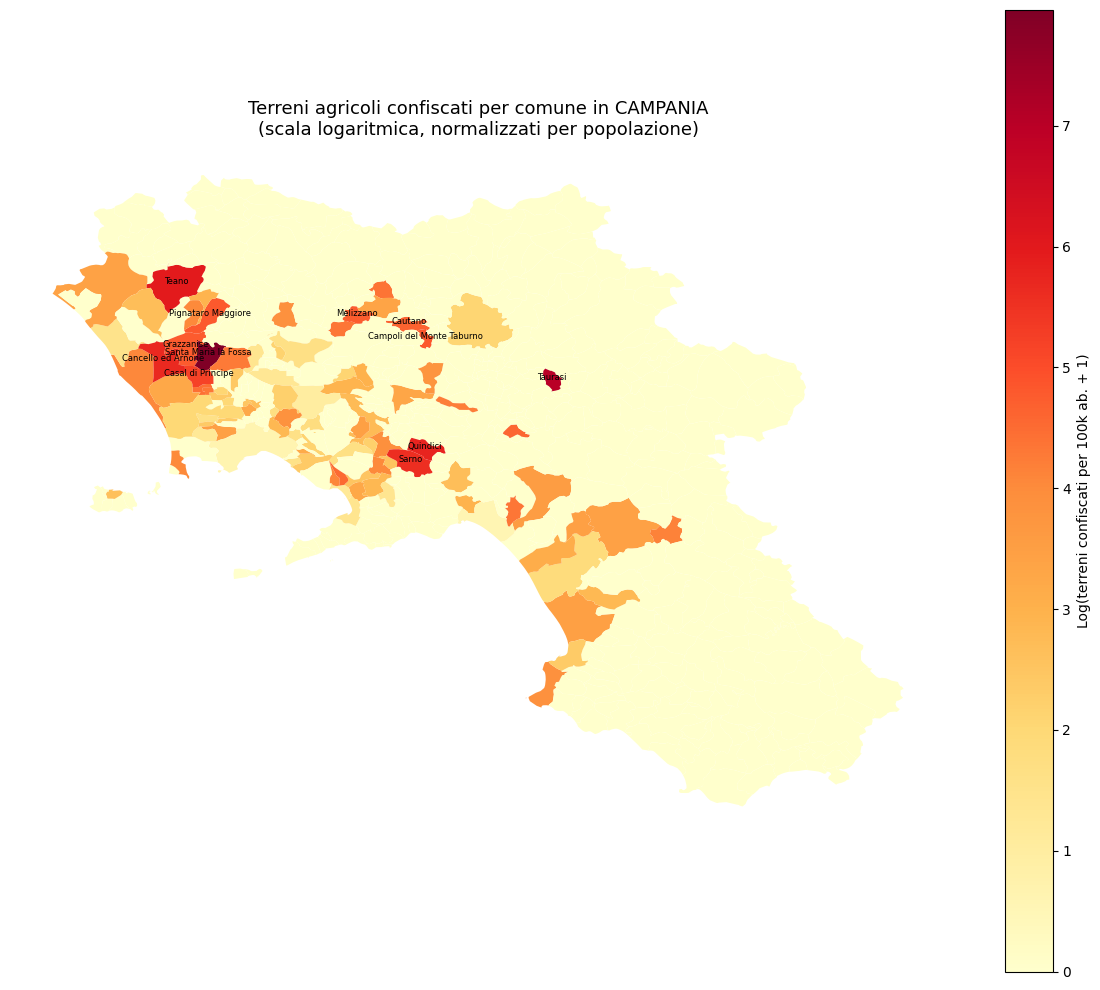

Salvata: mappa_terreni_campania_log.png

Top 10 comuni — CAMPANIA:
                   comune  n_terreni  terreni_per_100k
     Santa Maria la Fossa       73.0       2859.381120
                  Taurasi       24.0       1094.391245
                    Teano       44.0        382.010766
                 Quindici        6.0        317.796610
       Cancello ed Arnone       16.0        293.955539
                    Sarno       80.0        261.523374
        Casal di Principe       38.0        180.291313
Campoli del Monte Taburno        2.0        125.078174
       Pignataro Maggiore        7.0        121.002593
               Grazzanise        8.0        117.907148


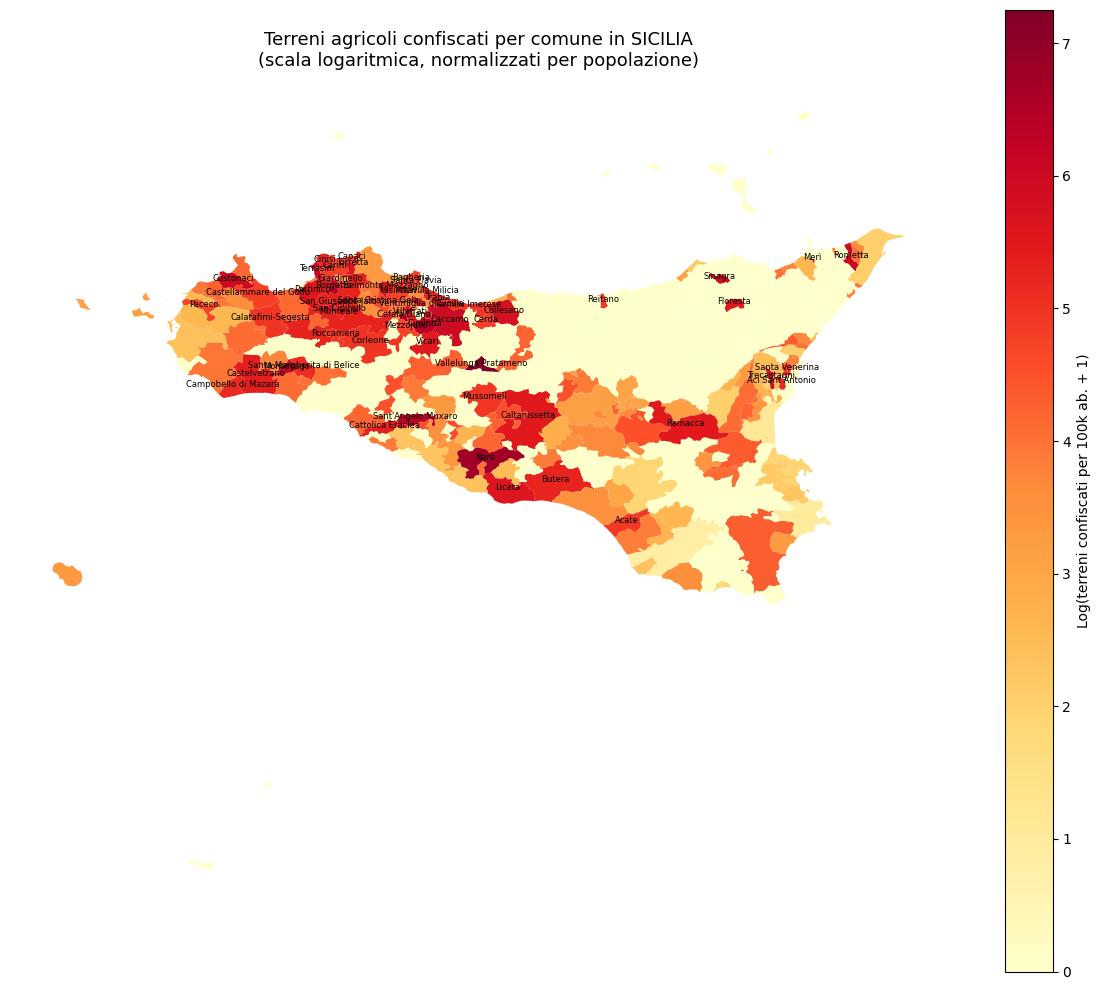

Salvata: mappa_terreni_sicilia_log.png

Top 10 comuni — SICILIA:
              comune  n_terreni  terreni_per_100k
Vallelunga Pratameno       45.0       1407.129456
                Naro       59.0        829.817159
        Cefalà Diana        7.0        703.517588
             Ciminna       22.0        631.276901
            Borgetto       37.0        523.412081
  Sant'Angelo Muxaro        6.0        506.756757
           Montevago       12.0        438.917337
                Merì       10.0        429.184549
             Rometta       26.0        404.984424
           Terrasini       50.0        400.544741


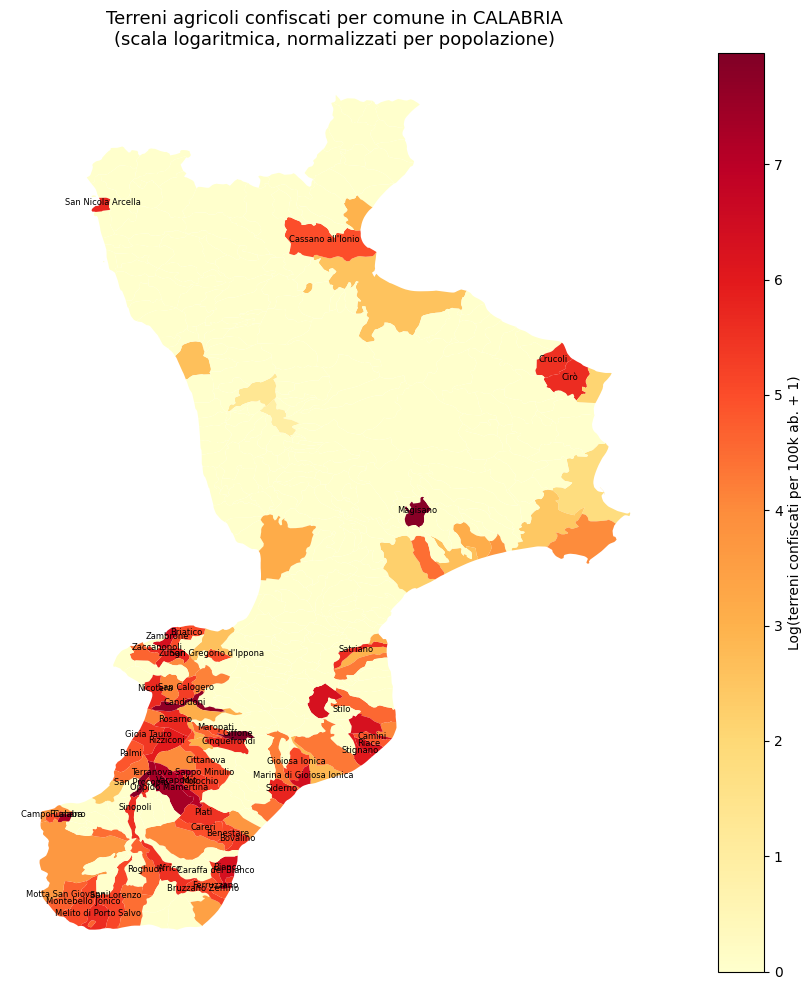

Salvata: mappa_terreni_calabria_log.png

Top 10 comuni — CALABRIA:
                  comune  n_terreni  terreni_per_100k
                 Giffone       46.0       2871.410737
                Magisano       28.0       2462.620932
            San Procopio       12.0       2348.336595
               Candidoni        9.0       2153.110048
        Oppido Mamertina       74.0       1511.129263
                 Fiumara       12.0       1377.726751
               Varapodio       24.0       1189.296333
 Terranova Sappo Minulio        5.0       1050.420168
Marina di Gioiosa Ionica       37.0        588.984400
                Zambrone       10.0        576.036866


In [30]:
# cod_reg: Campania=15, Sicilia=19, Calabria=18
mappa_regione(15, 'CAMPANIA', 'mappa_terreni_campania_log.png')
mappa_regione(19, 'SICILIA',  'mappa_terreni_sicilia_log.png')
mappa_regione(18, 'CALABRIA', 'mappa_terreni_calabria_log.png')

## Riepilogo risultati principali

| Modello | β | SE | p | R² | N |
|---|---|---|---|---|---|
| OLS baseline | 0.061 | 0.005 | <0.001 | 0.561 | 104 |
| SE robusti HC3 | 0.061 | 0.006 | <0.001 | 0.561 | 104 |
| No outlier | 0.057 | 0.005 | <0.001 | 0.554 | 102 |
| Solo prov. con confische | 0.059 | 0.006 | <0.001 | 0.603 | 70 |
| Regressori 2019 | 0.058 | 0.005 | <0.001 | 0.547 | 103 |
| Tutti i beni (VD alt.) | 0.032 | 0.007 | <0.001 | 0.191 | 98 |
| Spatial Lag ML | 0.026 | 0.006 | <0.001 | 0.728 | 104 |
| Tobit AME | 0.487 | — | — | — | 103 |
| FE regionali | 0.004 | 0.012 | 0.718 | 0.806 | 103 |

**Nota:** Il Tobit riporta l'effetto marginale medio (AME) sulla scala originale.
Il modello con FE regionali mostra che la relazione opera prevalentemente *tra* regioni.

---

**Riferimento:** Pica, G. (2026). *Esclusione dal mercato del lavoro e controllo mafioso del territorio agricolo: evidenza dalle province italiane.* Working paper.